Objective 1 (Regression – Simple LR)
To build a Simple Linear Regression model to predict property sale price from a single feature (e.g., TotalFinishedArea) and evaluate it using MAE, MSE, RMSE, and R².

Objective 2 (Regression – Multiple LR)
To build a Multiple Linear Regression model using multiple property features and compare its performance with Simple Linear Regression using MAE, MSE, RMSE, and R².

Objective 3 (Classification – multiple models)
To convert sale price into a binary class (High-price vs Low-price) and build Logistic Regression, Naïve Bayes, Decision Tree, SVM, and K-Nearest Neighbor (KNN) models, evaluating them using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC.

Objective 4 (Model comparison)
To compare the performance of the classification models and identify which algorithm works best for this dataset.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Real_Estate_Sales_10012020_to_Current.csv")
df.head()

,OBJECTID,PropertyID,xrCompositeLandUseID,xrBuildingTypeID,ParcelID,LocationStartNumber,ApartmentUnitNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,...,OwnerFirstName,PrimaryGrantor,SaleDate,SalePrice,TotalAppraisedValue,LegalReference,xrSalesValidityID,xrDeedID,AssrLandUse,GlobalID
0,1,8,3,6.0,121-698-063,77,NaN,STAFFORD ST,2,6000.0,...,LAKESHA,SCOTT NASTASSIA,2024/07/01 00:00:00+00,259000.0,187200,08275 0343,1,10,ONE FAMILY,{78B6AAB5-D21E-471C-85BE-022DAB2A80B7}
1,2,9,3,3.0,121-698-062,73,NaN,STAFFORD ST,2,6000.0,...,ARCADIO,DIAZ RAFAEL,2022/04/26 00:00:00+00,208000.0,192300,07948-0001,1,10,ONE FAMILY,{15F34650-E463-4047-8808-A056FCDA3E09}
2,3,12,3,6.0,144-698-066,61,NaN,STAFFORD ST,2,6000.0,...,CATIRIA,KERN THOMAS,2023/12/22 00:00:00+00,125000.0,148400,08197-0077,1,10,ONE FAMILY,{C6FCA409-022A-4F1B-A674-13996FD1FE86}
3,4,20,3,6.0,144-698-058,29,NaN,STAFFORD ST,2,6000.0,...,REBECA,RAMOS MIGUEL JR,2023/09/29 00:00:00+00,1.0,167300,08158 0179,5,8,ONE FAMILY,{4D1DDED3-EF58-4091-A5F1-C7CA38B38C74}
4,5,25,3,6.0,144-698-053,211,NaN,NEWINGTON AVE,2,5040.0,...,LOURDES,BAIJANATH BISSNOW P,2021/01/11 00:00:00+00,177000.0,197900,07701-0245,1,10,ONE FAMILY,{F2E9A7CC-96D2-47AE-A2C1-59745FBE9C9E}


In [3]:
df = df[(df["SalePrice"] > 0) & (df["TotalFinishedArea"] > 0)]


In [4]:

features = [
    "TotalFinishedArea",
    "LandSF",
    "LivingUnits",
    "xrPrimaryNeighborhoodID",
    "xrBuildingTypeID"
]

In [5]:
df = df.dropna(subset=features)

print("Cleaned data shape:", df.shape)

Cleaned data shape: (3637, 23)



=== Correlation with SalePrice ===
TotalFinishedArea          0.177951
LandSF                     0.051165
LivingUnits                0.171018
xrPrimaryNeighborhoodID    0.006901
xrBuildingTypeID           0.060919
SalePrice                  1.000000
Name: SalePrice, dtype: float64


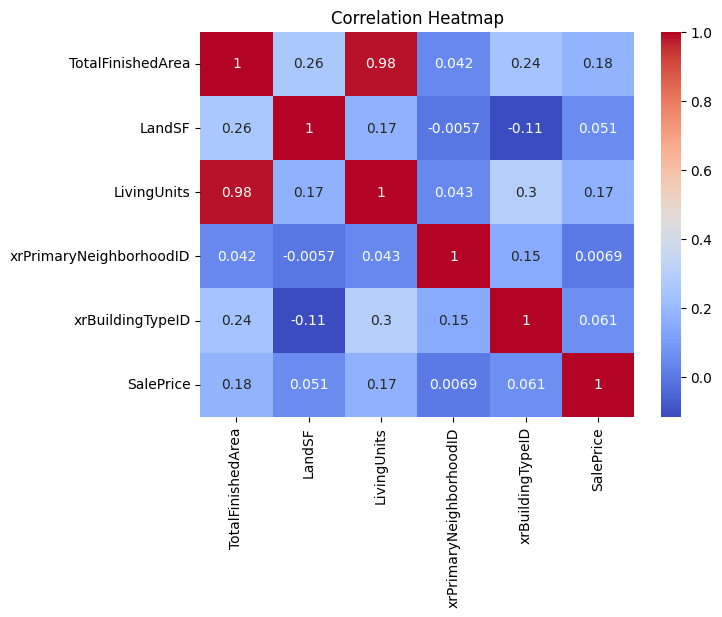

In [6]:
print(" Correlation with SalePrice ")
print(df[features + ["SalePrice"]].corr()["SalePrice"])

plt.figure(figsize=(7,5))
sns.heatmap(df[features + ["SalePrice"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


=== Simple Linear Regression ===
MAE : 327434.3894020836
MSE : 10665714921704.387
RMSE: 3265840.6148653957
R²  : 0.0008892176732515633


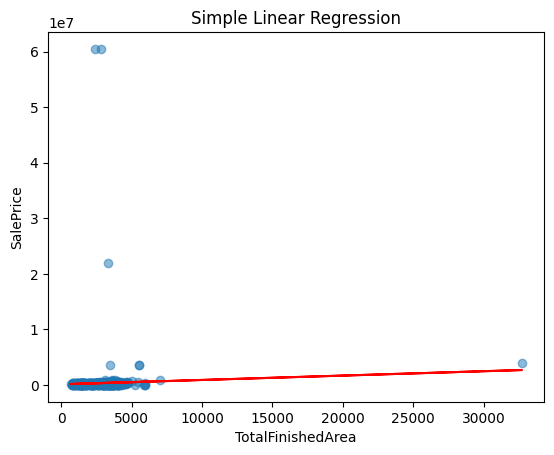

In [7]:
# SIMPLE LINEAR REGRESSION

X_slr = df[["TotalFinishedArea"]]
y_slr = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X_slr, y_slr, test_size=0.2, random_state=42)

slr = LinearRegression()
slr.fit(X_train, y_train)
y_pred = slr.predict(X_test)

print("Simple Linear Regression ")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

plt.scatter(X_test, y_test, alpha=0.5)
plt.plot(X_test, y_pred, color="red")
plt.xlabel("TotalFinishedArea")
plt.ylabel("SalePrice")
plt.title("Simple Linear Regression")
plt.show()


=== Multiple Linear Regression ===
MAE : 363560.5442131096
MSE : 10675611598250.39
RMSE: 3267355.4441245585
R²  : -3.785344377127409e-05


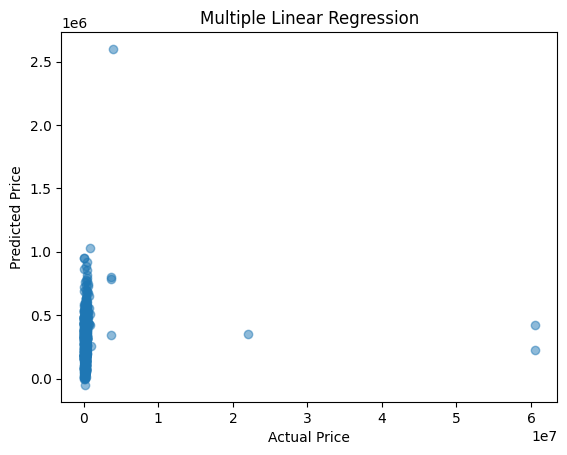

In [8]:
# MULTIPLE LINEAR REGRESSION
X_mlr = df[features]
y_mlr = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred = mlr.predict(X_test)

print(" Multiple Linear Regression ")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression")
plt.show()


In [9]:
# CLASSIFICATION PREP
# ============================
df["HighPrice"] = (df["SalePrice"] >= df["SalePrice"].median()).astype(int)

X_cls = df[features]
y_cls = df["HighPrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)


In [10]:
# SCALE FEATURES MANUALLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
# LOGISTIC REGRESSION
# ============================
log = LogisticRegression(max_iter=1000)
log.fit(X_train_scaled, y_train)
pred = log.predict(X_test_scaled)
prob = log.predict_proba(X_test_scaled)[:,1]

print("\n=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1-score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))


=== Logistic Regression ===
Accuracy : 0.6662087912087912
Precision: 0.6692111959287532
Recall   : 0.699468085106383
F1-score : 0.6840052015604682
ROC-AUC  : 0.7287838491295939
Confusion Matrix:
[[222 130]
 [113 263]]


In [12]:
# NAIVE BAYES
# ============================
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
pred = nb.predict(X_test_scaled)
prob = nb.predict_proba(X_test_scaled)[:,1]

print("\n=== Naive Bayes ===")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1-score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))


=== Naive Bayes ===
Accuracy : 0.6236263736263736
Precision: 0.6770833333333334
Recall   : 0.5186170212765957
F1-score : 0.5873493975903614
ROC-AUC  : 0.6923431455512572
Confusion Matrix:
[[259  93]
 [181 195]]


In [13]:
# DECISION TREE
# ============================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)   # Tree does not need scaling
pred = dt.predict(X_test)
prob = dt.predict_proba(X_test)[:,1]


print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1-score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))


=== Decision Tree ===
Accuracy : 0.5728021978021978
Precision: 0.5947521865889213
Recall   : 0.5425531914893617
F1-score : 0.5674547983310153
ROC-AUC  : 0.5646835710831721
Confusion Matrix:
[[213 139]
 [172 204]]


In [14]:
# SVM
# ============================
svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)
pred = svm.predict(X_test_scaled)
prob = svm.predict_proba(X_test_scaled)[:,1]

print("\n=== Support Vector Machine ===")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1-score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))


=== Support Vector Machine ===
Accuracy : 0.6634615384615384
Precision: 0.6585956416464891
Recall   : 0.723404255319149
F1-score : 0.6894803548795945
ROC-AUC  : 0.7162717601547388
Confusion Matrix:
[[211 141]
 [104 272]]


In [15]:
# KNN
# ============================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
prob = knn.predict_proba(X_test_scaled)[:,1]

print("\n=== K-Nearest Neighbor ===")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1-score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))


=== K-Nearest Neighbor ===
Accuracy : 0.6291208791208791
Precision: 0.6358974358974359
Recall   : 0.6595744680851063
F1-score : 0.6475195822454308
ROC-AUC  : 0.6693929823500968
Confusion Matrix:
[[210 142]
 [128 248]]


In [16]:
# ACCURACY COMPARISON
# ============================
print("\n=== Accuracy Comparison ===")
print("Logistic Regression:", accuracy_score(y_test, log.predict(X_test_scaled)))
print("Naive Bayes        :", accuracy_score(y_test, nb.predict(X_test_scaled)))
print("Decision Tree      :", accuracy_score(y_test, dt.predict(X_test)))
print("SVM                :", accuracy_score(y_test, svm.predict(X_test_scaled)))
print("KNN                :", accuracy_score(y_test, knn.predict(X_test_scaled)))


=== Accuracy Comparison ===
Logistic Regression: 0.6662087912087912
Naive Bayes        : 0.6236263736263736
Decision Tree      : 0.5728021978021978
SVM                : 0.6634615384615384
KNN                : 0.6291208791208791


In [18]:

# PREDICT CLASS (HIGH or LOW PRICE PROPERTY)


sample_house_cls = pd.DataFrame({
    "TotalFinishedArea": [2000],
    "LandSF": [6000],
    "LivingUnits": [1],
    "xrPrimaryNeighborhoodID": [200],
    "xrBuildingTypeID": [1]
})

sample_scaled = scaler.transform(sample_house_cls)

predicted_class = log.predict(sample_scaled)
predicted_prob = log.predict_proba(sample_scaled)

print("\n--- Classification Prediction Example ---")
print("Predicted Class:", "High Price" if predicted_class[0] == 1 else "Low Price")
print("Probability of High Price:", round(predicted_prob[0][1], 3))



--- Classification Prediction Example ---
Predicted Class: Low Price
Probability of High Price: 0.263


In [17]:
# ==============================
# PREDICT SALE PRICE (REGRESSION)
# ==============================

sample_house = pd.DataFrame({
    "TotalFinishedArea": [2000],
    "LandSF": [6000],
    "LivingUnits": [1],
    "xrPrimaryNeighborhoodID": [200],
    "xrBuildingTypeID": [1]
})

predicted_price = mlr.predict(sample_house)


print("Predicted Sale Price (best regression model):", round(predicted_price[0], 2))


Predicted Sale Price (best regression model): 232321.22
